# ModHav Synthetic Dataset v2

OPTION 3

In [10]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import ModHav_synthetic_dataset
from src.data.saving import svm_exists, load_parameter_train, load_svm_results
from src.kernel.metrics import geometric_difference
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.training_candidate import train_candidate_optuna_angles
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

In [11]:
# ── 1. Data ────────────────────────────────────────────────────────────────
X, y = ModHav_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

RESULTS_DIR = 'Results/ModHav Synthetic v2'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

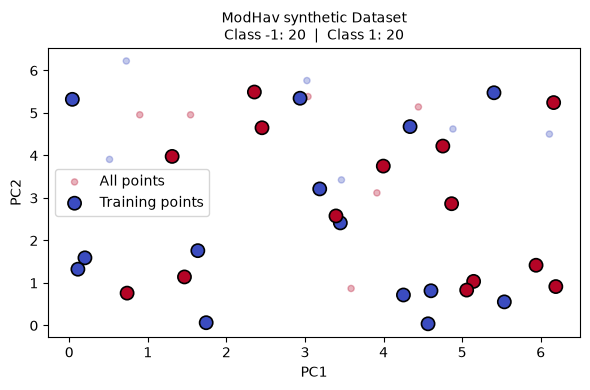

In [12]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('ModHav synthetic', X, y, X_train, y_train, 'yes')

In [13]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric', 'haar', 'angles', 'kta'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    ExperimentConfig(
        name='optuna kta',
        optimizer='optuna',
        variant='kta',
        subset_method='none',
        optimizer_kwargs={'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name='mealpy kta',
        optimizer='mealpy',
        variant='kta',
        subset_method='none',
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
]

In [14]:
# ── 4. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

2026/08/20 06:23:16 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=30, pop_size=20, pc=0.95, pm=0.1)



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna kta  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna kta'
Loading cached SVM results for 'optuna kta'

────────────────────────────────────────────────────────────
 mealpy kta  [mealpy + none]
────────────────────────────────────────────────────────────


2026/08/20 06:24:40 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 0.31295848235907253, Global best: 0.31295848235907253, Runtime: 45.47833 seconds
2026/08/20 06:25:25 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 0.32844803326035, Global best: 0.32844803326035, Runtime: 44.90515 seconds
2026/08/20 06:26:33 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 0.3704995340337848, Global best: 0.3704995340337848, Runtime: 68.22339 seconds
2026/08/20 06:29:19 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 0.3436544834846949, Global best: 0.3704995340337848, Runtime: 165.30595 seconds
2026/08/20 06:30:17 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 0.33496741476944203, Global best: 0.3704995340337848, Runtime: 58.59499 seconds
2026/08/20 06:31:01 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Probl

Saved candidate  → Results/ModHav Synthetic v2/mealpy kta/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/ModHav Synthetic v2/mealpy kta/svm.pkl

REPORT: mealpy kta | 30 epochs | 20 pop | 0.1 pm
Best C            : 0.1
Best CV accuracy  : 0.9167
Test accuracy     : 1.0000
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



In [27]:
data = load_parameter_train('optuna kta')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference optuna kta = {g:.4f}")

data = load_parameter_train('mealpy kta')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference mealpy kta = {g:.4f}")

Geometric difference optuna kta = 5.2353
Geometric difference mealpy kta = 6.6239


In [39]:
name='mealpy kta'
candidate = load_parameter_train(name)['candidate']
print(f"\n{name}")
print("     Gate   |   Angle")
for i, gene in enumerate(candidate.genes):
    print(f"{i:2d}:     {gene.gate}       {gene.angle:.2f}")


mealpy kta
     Gate   |   Angle
 0:     I       0.79
 1:     H       0.79
 2:     RY       0.79
 3:     I       3.14
 4:     I       0.39
 5:     I       0.39
 6:     I       0.79
 7:     I       3.14
 8:     I       0.39
 9:     I       0.39
10:     I       0.79
11:     RZ       0.39
12:     RZ       1.57
13:     CNOT       0.39
14:     RZ       1.57
15:     I       1.57


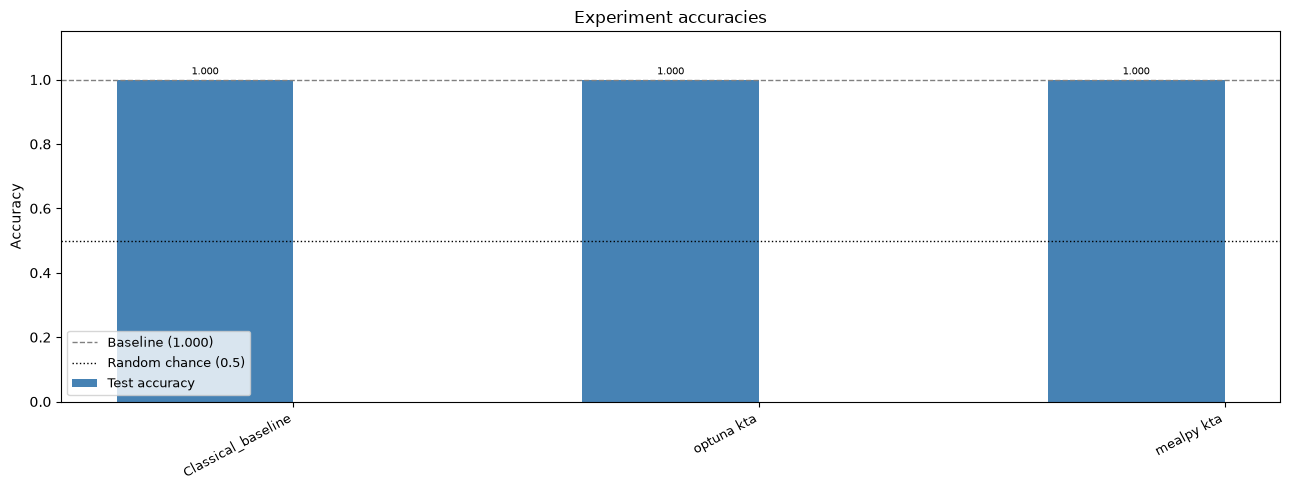

Saved → Results/ModHav Synthetic v2/accuracy_comparison.png


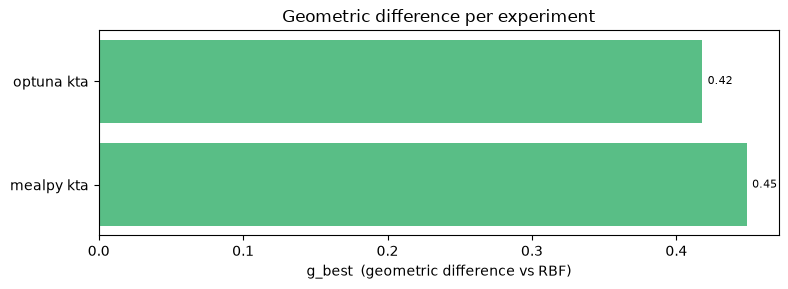

Saved → Results/ModHav Synthetic v2/g_best_comparison.png


In [18]:
# ── 6. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)

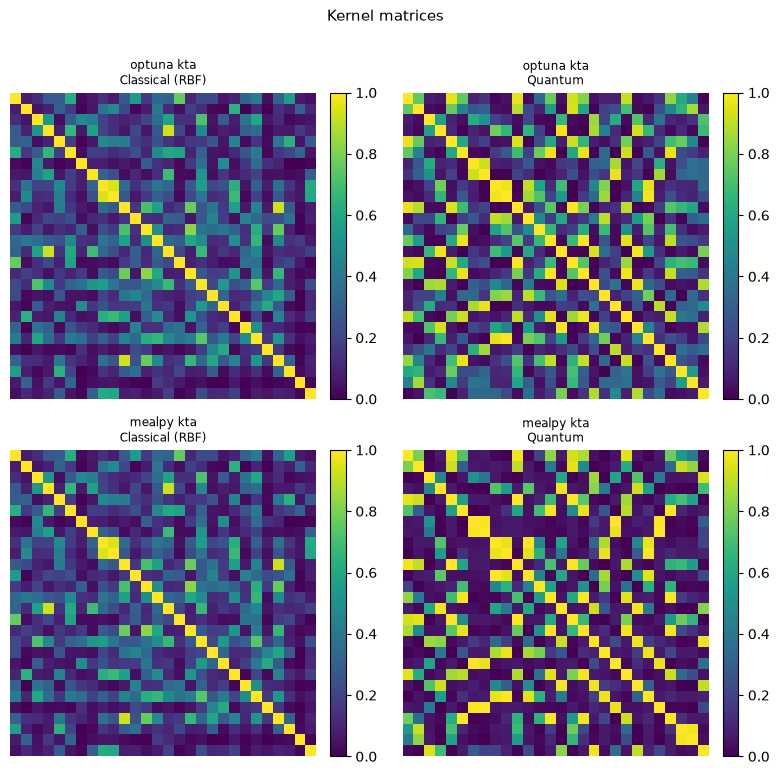

Saved → Results/ModHav Synthetic v2/kernel_heatmaps.png


In [17]:
plot_kernel_heatmaps(summary)